# Analyse Exploratoire

### Import des modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from sklearn.impute import KNNImputer
from scipy import stats
import bentoml

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

### Analyse Exploratoire

In [3]:
building_consumption = pd.read_csv('2016_Building_Energy_Benchmarking.csv')

In [4]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [5]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

In [6]:
building_consumption.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,3376.000000,3.376000e+03,3.356000e+03,1679.000000,596.000000,2533.000000,3369.000000,3370.000000,3367.000000,3367.000000,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,8001.526066,8.683201e+04,7.917764e+04,28444.075817,11738.675166,67.918674,54.732116,57.033798,134.232848,137.783932,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,32326.723928,2.079398e+05,2.017034e+05,54392.917928,29331.199286,26.873271,56.273124,57.163330,139.287554,139.109807,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-2.100000,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,0.000000,2.775600e+04,2.509475e+04,5000.000000,2239.000000,53.000000,27.900000,29.400000,74.699997,78.400002,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,0.000000,4.321600e+04,3.989400e+04,10664.000000,5043.000000,75.000000,38.599998,40.900002,96.199997,101.099998,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,0.000000,8.427625e+04,7.620025e+04,26640.000000,10138.750000,90.000000,60.400002,64.275002,143.899994,148.349998,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,686750.000000,459748.000000,100.000000,834.400024,834.400024,2620.000000,2620.000000,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


On observe des valeurs négatives pour **SourceEUIWN(kBtu/sf)**, **Electricity(kWh)**, **Electricity(kBtu)**, **TotalGHGEmissions** et **GHGEmissionsIntensity**. La logique est qu'un bâtiments avec des émissions ou consomation négatives ne peut l'être que si il produit plus que ce qu'il consomme et stock plus qu'il n'émet. Seul un bâtiments écologique peut avoir ces caractéristiques.

In [7]:
# Valeurs négatives peu probable
building_consumption[building_consumption['TotalGHGEmissions'] < 0]
building_consumption[building_consumption['SiteEnergyUse(kBtu)'] < 0]
building_consumption[building_consumption['Electricity(kWh)'] < 0]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
3206,49784,2016,NonResidential,Small- and Mid-Sized Office,Bullitt Center,1501 E. Madison St.,Seattle,WA,98122.0,7234600195,3,CENTRAL,47.61432,-122.31257,2013,1.0,6,52000,0,52000,Office,Office,48159.0,NaN,NaN,NaN,NaN,NaN,100.0,7.1,5.0,2.0,-2.1,342726.0938,240132.0938,0.0,-33826.80078,-115417.0,0.0,0.0,False,NaN,Compliant,NaN,-0.8,-0.02


Le bâtiment en question est le **Bulitt Center**. un bâtiments à énergie positive avec panneaux solaires. Je le supprime du dataset car il risque de fausser le projet.

In [8]:
# Affiche le nombres de lignes avant modification du fichier
nb_avant = len(building_consumption)

building_consumption = building_consumption[building_consumption['OSEBuildingID'] != 49784]
# Affiche le nombres de lignes après modification du fichier
nb_apres = len(building_consumption)
print(f"Avant : {nb_avant} → Après : {nb_apres} ({nb_avant - nb_apres} ligne supprimée)")

Avant : 3376 → Après : 3375 (1 ligne supprimée)


## Building type
On ne veut garder que les bâtiments non-résidentiels

In [9]:
building_consumption['BuildingType'].value_counts()

BuildingType
NonResidential          1459
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

Je supprime les lignes **Multifamily LR (1-4)**,**Multifamily MR (5-9)**,**Multifamily HR (10+)** et **Campus** car se sont des lignes de bâtiments résidentiel.

In [10]:
# Types résidentiels à exclure
types_residentiel = ['Multifamily LR (1-4)','Multifamily MR (5-9)','Multifamily HR (10+)','Campus']

n_avant = len(building_consumption)

building_consumption = building_consumption[~building_consumption['BuildingType'].isin(types_residentiel)]

n_apres = len(building_consumption)
print(f"Avant : {n_avant} → Après : {n_apres} ({n_avant - n_apres} lignes supprimées)")

Avant : 3375 → Après : 1643 (1732 lignes supprimées)


In [11]:
building_consumption['PrimaryPropertyType'].value_counts()

PrimaryPropertyType
Small- and Mid-Sized Office    291
Other                          243
Warehouse                      187
Large Office                   172
K-12 School                    135
Mixed Use Property             110
Retail Store                    91
Hotel                           76
Worship Facility                71
Distribution Center             53
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
Residence Hall                  21
Senior Care Community           20
University                      18
Refrigerated Warehouse          12
Restaurant                      11
Hospital                        10
Laboratory                      10
Office                           3
Low-Rise Multifamily             2
Name: count, dtype: int64

In [12]:
nb_avant = len(building_consumption)
building_consumption = building_consumption[
    building_consumption['PrimaryPropertyType'] != 'Low-Rise Multifamily'
]
nb_apres = len(building_consumption)
print(f"Avant : {nb_avant} → Après : {nb_apres} ({nb_avant - nb_apres} ligne supprimée)")

Avant : 1643 → Après : 1641 (2 ligne supprimée)


## DefaultData
Les bâtiments avec DefaultData = True ont des valeurs estimées et non mesurées.
On les conserve car ils représentent précisément le cas d'usage du projet :
prédire la consommation de bâtiments non encore mesurés.

In [13]:
building_consumption['DefaultData'].value_counts()

DefaultData
False    1553
True       88
Name: count, dtype: int64

## Outlier
Cette colonne indique des valeurs abérentes définis par la ville de Seatle. Seul 17 lignes ont des valeurs abérentes. Je choisis de les supprimer.

In [14]:
building_consumption['Outlier'].value_counts()

Outlier
Low outlier     14
High outlier     2
Name: count, dtype: int64

In [15]:
# Types outlier à exclure
outlier = ['Low outlier','High outlier']

n_avant = len(building_consumption)

building_consumption = building_consumption[~building_consumption['Outlier'].isin(outlier)]

n_apres = len(building_consumption)
print(f"Avant : {n_avant} → Après : {n_apres} ({n_avant - n_apres} lignes supprimées)")

Avant : 1641 → Après : 1625 (16 lignes supprimées)


## Détecter les valeurs manquantes
Les colonnes Comments et Outlier ont 100% de valeurs nul. Je les supprime.
2 bâtiments (ID 773 et 26532) ont la quasi-totalité de leurs valeurs à NaN.
Supprimés car inexploitables pour la modélisation.

In [16]:
building_consumption.isnull().sum()

OSEBuildingID                         0
DataYear                              0
BuildingType                          0
PrimaryPropertyType                   0
PropertyName                          0
Address                               0
City                                  0
State                                 0
ZipCode                              16
TaxParcelIdentificationNumber         0
CouncilDistrictCode                   0
Neighborhood                          0
Latitude                              0
Longitude                             0
YearBuilt                             0
NumberofBuildings                     2
NumberofFloors                        0
PropertyGFATotal                      0
PropertyGFAParking                    0
PropertyGFABuilding(s)                0
ListOfAllPropertyUseTypes             2
LargestPropertyUseType                6
LargestPropertyUseTypeGFA             6
SecondLargestPropertyUseType        788
SecondLargestPropertyUseTypeGFA     788


In [17]:
building_consumption[building_consumption['TotalGHGEmissions'].isnull()]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
578,773,2016,NonResidential,Small- and Mid-Sized Office,SEATTLE BUILDING,215 COLUMBIA ST,Seattle,WA,98104.0,0939000245,7,DOWNTOWN,47.60380,-122.33293,1924,NaN,4,63150,0,63150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,Non-Compliant,NaN,NaN,NaN
2670,26532,2016,NonResidential,Mixed Use Property,KALBERG BUILDING,4515 UNIVERSITY WAY NE,Seattle,WA,98105.0,8816401120,4,NORTHEAST,47.66182,-122.31345,1928,NaN,2,20760,0,20760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,Non-Compliant,NaN,NaN,NaN


In [18]:
# Suppression des lignes contenants trop de valeurs nul
nb_avant = len(building_consumption)

building_consumption = building_consumption[building_consumption['TotalGHGEmissions'].notna()]

nb_apres = len(building_consumption)
print(f"Avant : {nb_avant} → Après : {nb_apres} ({nb_avant - nb_apres} lignes supprimées)")

Avant : 1625 → Après : 1623 (2 lignes supprimées)


In [19]:
# Suppressions des colonnes Outlier et Comments
nb_avant = building_consumption.shape[1]

building_consumption = building_consumption.drop(columns=['Outlier', 'Comments'])

nb_apres = building_consumption.shape[1]
print(f"Colonnes : {nb_avant} → {nb_apres} ({nb_avant - nb_apres} supprimées)")

Colonnes : 46 → 44 (2 supprimées)


## Détecter les doublons
Il n'y a pas de doublons

In [20]:
building_consumption.duplicated().sum()

np.int64(0)

## Corriger les types de données
**ZipCode** et **NumberofBuildings** doivent être de type Int
**CouncilDistrictCode**, **BuildingType**, **PrimaryPropertyType**, **Neighborhood**, **LargestPropertyUseType** et **ComplianceStatus** doivent être de type category.

In [21]:
# Vérifier les types actuels
building_consumption.dtypes

OSEBuildingID                        int64
DataYear                             int64
BuildingType                        object
PrimaryPropertyType                 object
PropertyName                        object
Address                             object
City                                object
State                               object
ZipCode                            float64
TaxParcelIdentificationNumber       object
CouncilDistrictCode                  int64
Neighborhood                        object
Latitude                           float64
Longitude                          float64
YearBuilt                            int64
NumberofBuildings                  float64
NumberofFloors                       int64
PropertyGFATotal                     int64
PropertyGFAParking                   int64
PropertyGFABuilding(s)               int64
ListOfAllPropertyUseTypes           object
LargestPropertyUseType              object
LargestPropertyUseTypeGFA          float64
SecondLarge

In [22]:
# Modifications au bon type
building_consumption['ZipCode'] = building_consumption['ZipCode'].astype('Int64')
building_consumption['NumberofBuildings'] = building_consumption['NumberofBuildings'].astype('Int64')
building_consumption[['BuildingType', 'PrimaryPropertyType', 'Neighborhood','LargestPropertyUseType', 
                      'ComplianceStatus','CouncilDistrictCode']] = building_consumption[['BuildingType', 'PrimaryPropertyType', 
                                                                                         'Neighborhood','LargestPropertyUseType', 
                                                                                         'ComplianceStatus',
                                                                                         'CouncilDistrictCode']].astype('category')


In [23]:
building_consumption.dtypes

OSEBuildingID                         int64
DataYear                              int64
BuildingType                       category
PrimaryPropertyType                category
PropertyName                         object
Address                              object
City                                 object
State                                object
ZipCode                               Int64
TaxParcelIdentificationNumber        object
CouncilDistrictCode                category
Neighborhood                       category
Latitude                            float64
Longitude                           float64
YearBuilt                             int64
NumberofBuildings                     Int64
NumberofFloors                        int64
PropertyGFATotal                      int64
PropertyGFAParking                    int64
PropertyGFABuilding(s)                int64
ListOfAllPropertyUseTypes            object
LargestPropertyUseType             category
LargestPropertyUseTypeGFA       

**NERGYSTARScore**
549 valeurs manquantes (33%) ont été imputées par la médiane du groupe **PrimaryPropertyType**. Un hôpital reçoit la médiane des hôpitaux, une école la médiane des écoles — plus représentatif qu'une médiane globale.
Malgrès tout il reste 67 Nan, je leurs impute  donc la médiane grobale.

In [24]:
# Imputation par médiane par type de bâtiment
building_consumption['ENERGYSTARScore'] = building_consumption.groupby(
   'PrimaryPropertyType',observed=True)['ENERGYSTARScore'].transform(
     lambda x: x.fillna(x.median()))

# Vérification
print(f"NaN restants : {building_consumption['ENERGYSTARScore'].isnull().sum()}")

NaN restants : 67


In [25]:
 # Imputer les 67 NaN restants avec la médiane globale
building_consumption['ENERGYSTARScore'] = building_consumption['ENERGYSTARScore'].fillna(
    building_consumption['ENERGYSTARScore'].median()
)

# Vérification
print(f"NaN restants : {building_consumption['ENERGYSTARScore'].isnull().sum()}")

NaN restants : 0


In [26]:
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1623 entries, 0 to 3375
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   OSEBuildingID                    1623 non-null   int64   
 1   DataYear                         1623 non-null   int64   
 2   BuildingType                     1623 non-null   category
 3   PrimaryPropertyType              1623 non-null   category
 4   PropertyName                     1623 non-null   object  
 5   Address                          1623 non-null   object  
 6   City                             1623 non-null   object  
 7   State                            1623 non-null   object  
 8   ZipCode                          1607 non-null   Int64   
 9   TaxParcelIdentificationNumber    1623 non-null   object  
 10  CouncilDistrictCode              1623 non-null   category
 11  Neighborhood                     1623 non-null   category
 12  Latitude   

## Suppression des colonnes non pertinentes

Les colonnes suivantes ont été supprimées pour les raisons suivantes :

- **OSEBuildingID** : identifiant technique unique par bâtiment, aucune valeur prédictive
- **DataYear** : toutes les valeurs sont 2016 (écart-type = 0), aucune information
- **TaxParcelIdentificationNumber** : identifiant fiscal, aucune valeur prédictive
- **YearsENERGYSTARCertified** : 96% de valeurs manquantes (3257/3376), trop peu de données exploitables
- **Address** : redondant avec Latitude et Longitude qui encodent déjà la position géographique
- **City** : tous les bâtiments sont à Seattle, aucune variabilité
- **State** : tous les bâtiments sont dans l'état WA, aucune variabilité
- **PropertyName** : nom propre du bâtiment, aucune valeur prédictive pour le modèle
- **ComplianceStatus** : Redondant avec DafaultData

    Je garde certaines colonnes pour créer des features plus tard.

In [27]:
cols_a_supprimer = ['OSEBuildingID',
    'DataYear','TaxParcelIdentificationNumber','YearsENERGYSTARCertified',
    'Address','City','State','PropertyName','ComplianceStatus'
]

nb_avant = building_consumption.shape[1]
building_consumption = building_consumption.drop(columns=cols_a_supprimer)
nb_apres = building_consumption.shape[1]
print(f"Colonnes : {nb_avant} → {nb_apres} ({nb_avant - nb_apres} supprimées)")

Colonnes : 44 → 35 (9 supprimées)


## Sélection des features et de la target

### Target principale
- **TotalGHGEmissions** : émissions totales de CO2 du bâtiment (en tonnes)

### Target secondaire
- **SiteEnergyUse(kBtu)** : consommation totale d'énergie du bâtiment

### Features retenues
Les features sélectionnées correspondent aux caractéristiques structurelles
et géographiques des bâtiments, conformément à l'objectif du projet :
prédire la consommation énergétique à partir des données disponibles
sans mesure préalable.

- **BuildingType** : type de bâtiment (non résidentiel, école, campus...)
- **PrimaryPropertyType** : usage principal du bâtiment
- **Neighborhood** : quartier de Seattle
- **Latitude / Longitude** : localisation géographique
- **YearBuilt** : année de construction
- **NumberofBuildings** : nombre de bâtiments sur le site
- **NumberofFloors** : nombre d'étages
- **PropertyGFATotal** : surface totale brute du site
- **PropertyGFAParking** : surface dédiée au parking
- **LargestPropertyUseType** : type d'usage principal détaillé
- **SecondLargestPropertyUseType** : second usage du bâtiment
- **ThirdLargestPropertyUseType** : troisième usage du bâtiment
- **ENERGYSTARScore** : score de performance énergétique (imputé par médiane par type)
- **DefaultData** : indique si les données sont estimées ou mesurées
- **ComplianceStatus** : statut de conformité du bâtiment
- **Electricity(kWh)** : consommation électrique (utilisée pour créer HasElectricity)
- **NaturalGas(therms)** : consommation gaz (utilisée pour créer HasGas)
- **SteamUse(kBtu)** : consommation vapeur (utilisée pour créer HasSteam)

### Features créées (Feature Engineering)
Ces features seront construites à partir des colonnes brutes ci-dessus,
puis les colonnes sources seront supprimées.

- **GFAperFloor** : surface moyenne par étage (PropertyGFATotal / NumberofFloors)
- **HasParking** : présence d'un parking (binaire)
- **HasElectricity** : raccordement électrique (binaire)
- **HasGas** : raccordement au gaz naturel (binaire)
- **HasSteam** : raccordement au réseau de vapeur de Seattle (binaire)
- **NombreUsages** : nombre d'usages différents dans le bâtiment

In [28]:
# Colonnes à conserver
cols_a_garder = [
    'BuildingType',
    'PrimaryPropertyType',
    'Neighborhood',
    'Latitude',
    'Longitude',
    'YearBuilt',
    'NumberofBuildings',
    'NumberofFloors',
    'PropertyGFATotal',
    'PropertyGFAParking',
    'PropertyGFABuilding(s)',
    'LargestPropertyUseType',
    'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseType',
    'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseType',
    'ThirdLargestPropertyUseTypeGFA',
    'ENERGYSTARScore',
    'DefaultData',
    'Electricity(kWh)',
    'NaturalGas(therms)',
    'SteamUse(kBtu)',
    'TotalGHGEmissions',
    'SiteEnergyUse(kBtu)',
]
nb_avant = building_consumption.shape[1]
building_consumption = building_consumption[cols_a_garder]
nb_apres = building_consumption.shape[1]
print(f"Colonnes : {nb_avant} → {nb_apres} ({nb_avant - nb_apres} supprimées)")

Colonnes : 35 → 24 (11 supprimées)


## Transformation logarithmique des variables asymétriques

La majorité des variables numériques présentent une distribution fortement asymétrique
(queue longue à droite) : la plupart des bâtiments ont de faibles valeurs, mais quelques
grands bâtiments (hôpitaux, universités) ont des valeurs extrêmement élevées.

Ce type de distribution pose problème pour les modèles de machine learning car :
- Le modèle accorde trop d'importance aux grandes valeurs
- Les relations entre variables ne sont pas linéaires
- Les prédictions sur les bâtiments "moyens" sont moins précises

La transformation logarithmique (np.log1p) permet de :
- Rendre la distribution plus symétrique et proche d'une loi normale
- Équilibrer le poids de chaque bâtiment dans l'apprentissage
- Linéariser les relations entre variables

Les colonnes concernées sont :
- Les surfaces : PropertyGFATotal, PropertyGFAParking, PropertyGFABuilding(s), LargestPropertyUseTypeGFA
- Les consommations : SiteEnergyUse(kBtu), SteamUse(kBtu), Electricity(kWh), NaturalGas(therms)
- Les émissions : TotalGHGEmissions, GHGEmissionsIntensity
- Les intensités énergétiques : SiteEUI(kBtu/sf), SourceEUI(kBtu/sf)

Note : np.log1p est utilisé à la place de np.log car il gère correctement les valeurs
égales à 0 (log(0) est indéfini, log1p(0) = 0).

In [29]:
# Sélection des colonnes
cols_log = [
    'PropertyGFATotal', 'PropertyGFABuilding(s)',
    'LargestPropertyUseTypeGFA', 'SiteEnergyUse(kBtu)',  'TotalGHGEmissions'
]
# Transformation logarythmique des colonnes choisis
for col in cols_log:
    building_consumption[col + '_log'] = np.log1p(building_consumption[col])
#suppression des colonnes originales
building_consumption = building_consumption.drop(columns=cols_log)
building_consumption.shape

(1623, 24)

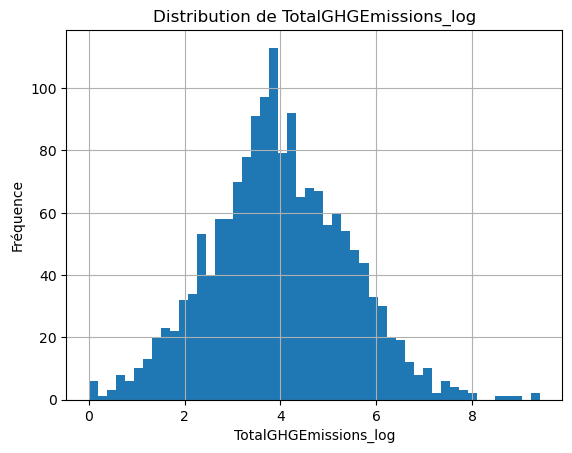

In [30]:
building_consumption['TotalGHGEmissions_log'].hist(bins=50)
plt.title("Distribution de TotalGHGEmissions_log")
plt.xlabel("TotalGHGEmissions_log")
plt.ylabel("Fréquence")
plt.show()

Les Outliers correspondent à des hopitaux. La logique est que se sont les bâtiments qui consomment et donc 
émètent le plus car ils tournent 24/7 et qu'ils ont du matèriel très consommateur

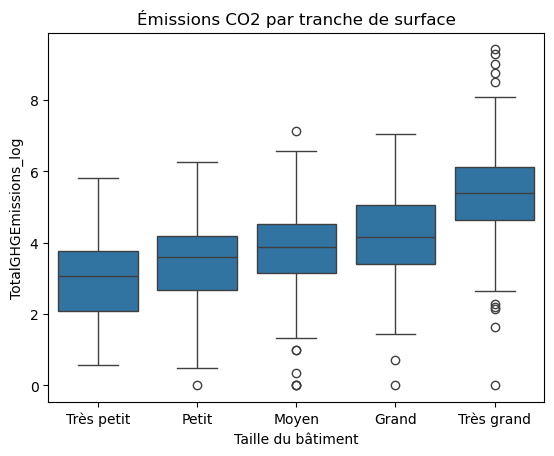

In [31]:
# Discrétiser la surface en 5 tranches égales
building_consumption['GFA_bins'] = pd.qcut(
    building_consumption['PropertyGFATotal_log'],
    q=5,
    labels=['Très petit', 'Petit', 'Moyen', 'Grand', 'Très grand']
)

# Boxplot surface vs émissions
sns.boxplot(data=building_consumption, 
            x='GFA_bins', 
            y='TotalGHGEmissions_log')
plt.title("Émissions CO2 par tranche de surface")
plt.xlabel("Taille du bâtiment")
plt.ylabel("TotalGHGEmissions_log")
plt.show()

# Supprimer la colonne temporaire
building_consumption = building_consumption.drop(columns=['GFA_bins'])

Cela me permet de visualiser la relation entre la surface et les émissions

## Détection des outliers sur les variables transformées

Après transformation logarithmique, on vérifie visuellement la présence
d'outliers résiduels sur les colonnes numériques via des boxplots.
Les outliers signalés par la ville ont déjà été supprimés en amont,
ainsi que le Bullitt Center (bâtiment à énergie positive atypique).

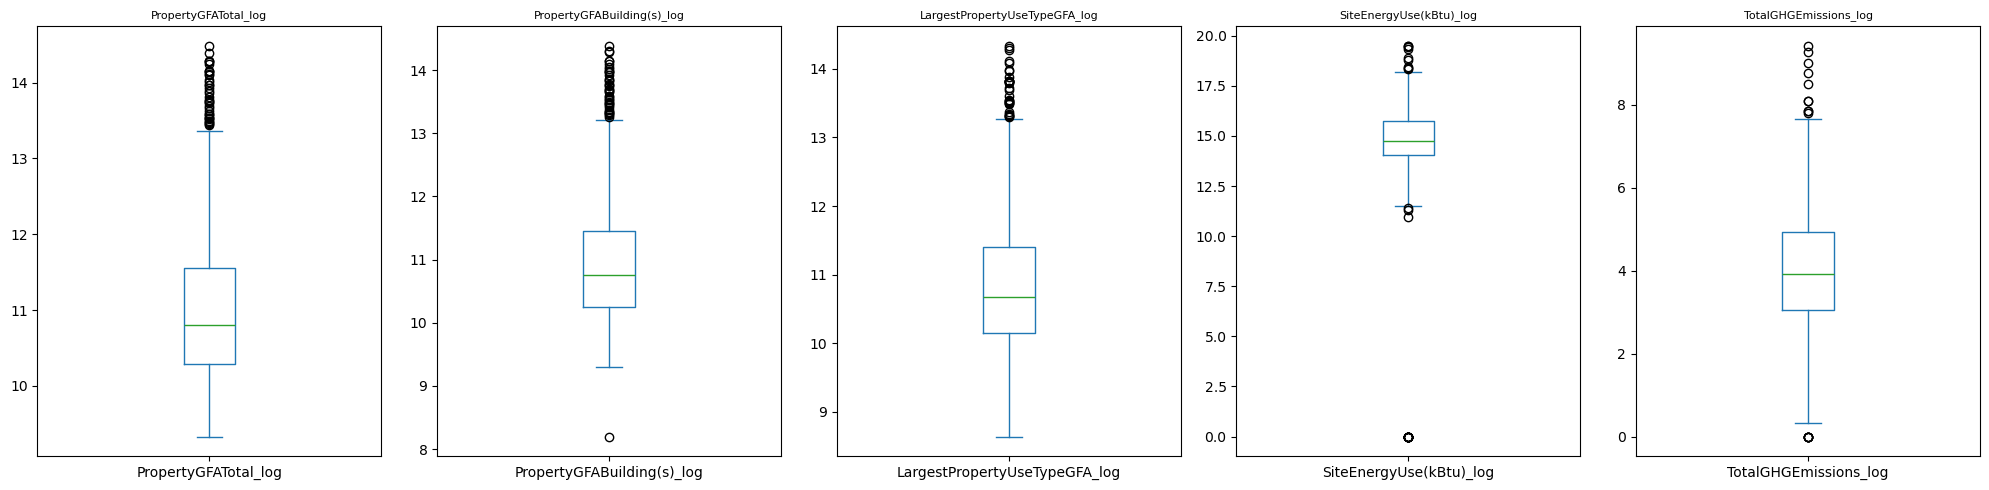

In [32]:
cols_log_names = [col for col in building_consumption.columns if '_log' in col]

fig, axes = plt.subplots(nrows=1, ncols=len(cols_log_names), figsize=(20, 5))

for i, col in enumerate(cols_log_names):
    building_consumption[col].plot(kind='box', ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

## Conclusion — Boxplots après transformation logarithmique

Les boxplots confirment que les distributions sont propres après transformation :
- Les boîtes sont bien centrées et symétriques pour la majorité des variables
- Les quelques points isolés visibles sont des cas limites acceptables,
  non comparables aux valeurs extrêmes observées avant transformation
- Aucun outlier aberrant ne justifie une suppression supplémentaire

On peut passer à l'analyse des corrélations entre features et target.

# Modélisation


## Import des modules 

In [33]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
    KFold
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

### Feature Engineering
A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

## Feature Engineering

### Features créées

Ces features seront construites à partir des colonnes brutes ci-dessus,
puis les colonnes sources seront supprimées.

- **GFAperFloor** : surface moyenne par étage (PropertyGFATotal / NumberofFloors)
- **HasParking** : présence d'un parking (binaire)
- **HasElectricity** : raccordement électrique (binaire)
- **HasGas** : raccordement au gaz naturel (binaire)
- **HasSteam** : raccordement au réseau de vapeur de Seattle (binaire)
- **NombreUsages** : nombre d'usages différents dans le bâtiment

In [34]:
# CODE FEATURE ENGINEERING
# Surface par étage
building_consumption['GFAperFloor'] = (
    np.expm1(building_consumption['PropertyGFATotal_log']) / 
    building_consumption['NumberofFloors'].replace(0, 1)
)

# Présence de parking
building_consumption['HasParking'] = (
    building_consumption['PropertyGFAParking'] > 0).astype(int)


## Préparation des features pour la modélisation
A réaliser :

Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation. Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer. Débarrassez-vous des features redondantes en utilisant une matrice de corrélation. Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé). Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target). Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.



## Analyse de la matrice de corrélation

### Corrélations avec la target principale (TotalGHGEmissions_log)
Les features les plus corrélées avec les émissions CO2 sont :
- **SiteEnergyUse(kBtu)_log** (0.65) : logique — consommation et émissions sont naturellement liées
- **PropertyGFATotal_log** (0.59) : plus le bâtiment est grand, plus il émet
- **PropertyGFABuilding(s)_log** (0.59) : même logique que la surface totale
- **LargestPropertyUseTypeGFA_log** (0.57) : la surface de l'usage principal est liée aux émissions
- **Electricity(kWh)** (0.49) : la consommation électrique est liée aux émissions
- **NaturalGas(therms)** (0.46) : le gaz contribue directement aux émissions CO2
- **SecondLargestPropertyUseTypeGFA** (0.41) : la surface du second usage est modérément liée
- **NumberofFloors** (0.31) : corrélation modérée
- **SteamUse(kBtu)** (0.24) : faible corrélation
- **YearBuilt** (0.15) : faible corrélation

### Multicolinéarité détectée
Plusieurs colonnes mesurent quasiment la même chose (la surface du bâtiment) :
- PropertyGFATotal_log / PropertyGFABuilding(s)_log → 0.98
- PropertyGFATotal_log / LargestPropertyUseTypeGFA_log → 0.94
- PropertyGFABuilding(s)_log / LargestPropertyUseTypeGFA_log → 0.94
- SecondLargestPropertyUseTypeGFA / ThirdLargestPropertyUseTypeGFA → 0.60

Conserver ces colonnes introduirait de la multicolinéarité dans le modèle,
ce qui rendrait les coefficients instables et fausserait l'importance des features.
On conserve uniquement **PropertyGFATotal_log** comme indicateur de surface
et on supprime PropertyGFABuilding(s)_log et LargestPropertyUseTypeGFA_log.

Note : Electricity(kWh), NaturalGas(therms) et SteamUse(kBtu) seront
transformées en features binaires (HasElectricity, HasGas, HasSteam)
pour conserver uniquement l'information structurelle de raccordement
sans introduire de data leakage.

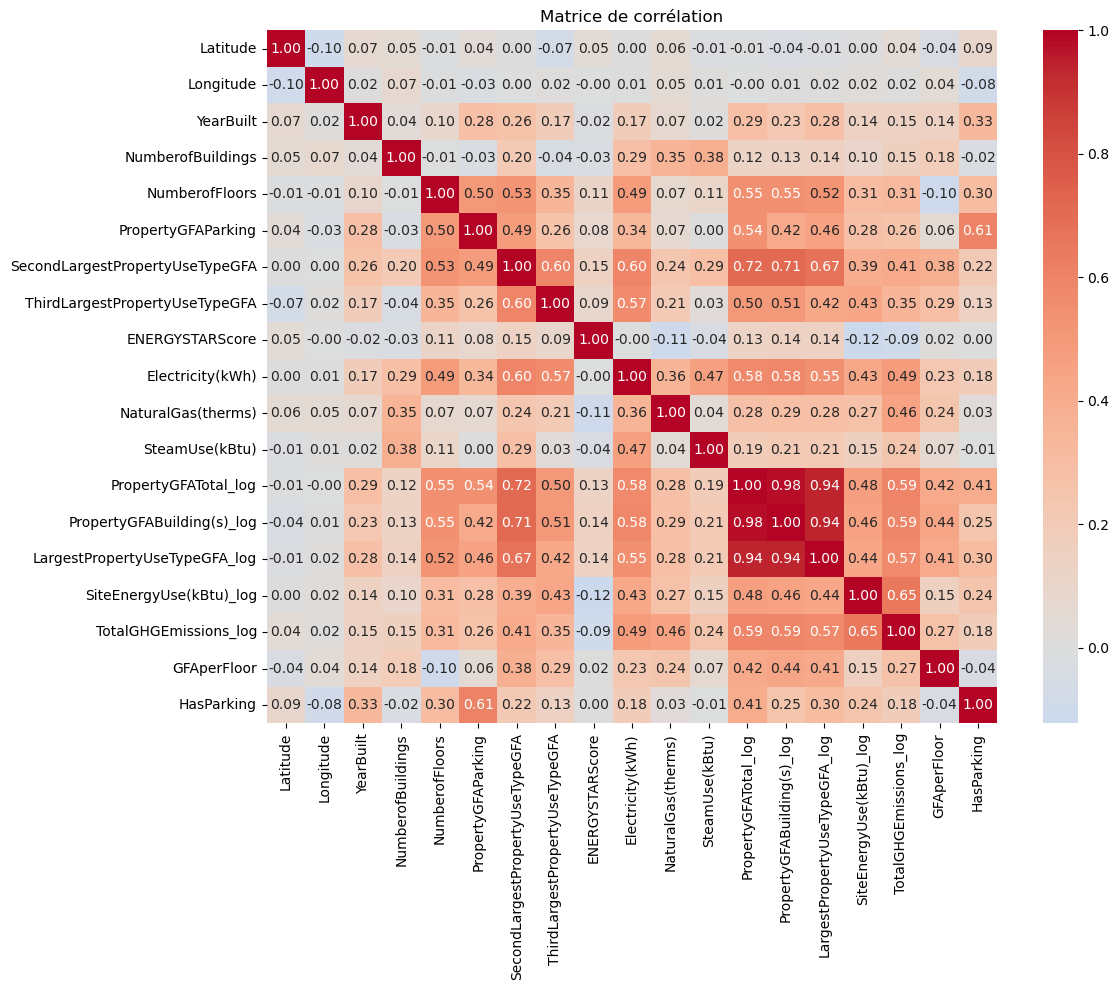

In [35]:
# Matrice de corrélation sur les variables numériques
corr = building_consumption.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

In [36]:
cols_a_garder = [
    # Top features 
    'PrimaryPropertyType',
    'Neighborhood',
    'YearBuilt',
    'NumberofFloors',
    'PropertyGFATotal_log',
    'PropertyGFAParking',
    'ENERGYSTARScore',
    # Feature engineering — mix énergétique (seront transformées en binaire)
    'NaturalGas(therms)',
    'SteamUse(kBtu)',
    # Target
    'TotalGHGEmissions_log',
    'SiteEnergyUse(kBtu)_log'
]

building_consumption = building_consumption[cols_a_garder]
print(building_consumption.shape)

(1623, 11)


## Choix de la target

La target retenue pour la modélisation est **TotalGHGEmissions_log**.

**Pourquoi TotalGHGEmissions ?**
- C'est la variable directement liée à l'objectif du projet : aider Seattle
  à atteindre la neutralité carbone en 2050
- Elle est fortement corrélée avec SiteEnergyUse(kBtu) (0.65) — prédire
  les émissions revient indirectement à prédire la consommation énergétique
- La transformation logarithmique (TotalGHGEmissions_log) a permis d'obtenir
  une distribution proche de la normale, favorable à la modélisation

On peut donc supprimer SiteEnergyUse(kBtu)_log du DataFrame final.

In [37]:
building_consumption = building_consumption.drop(columns=['SiteEnergyUse(kBtu)_log'])
print(building_consumption.shape)

(1623, 10)


## Création des nouvelles features (Feature Engineering)

Deux nouvelles features ont été créées à partir des colonnes existantes
afin d'enrichir le jeu de données pour la modélisation.

### GFAperFloor — Surface moyenne par étage

Surface totale divisée par le nombre d'étages.
Le replace(0, 1) évite une division par zéro pour les bâtiments
dont le nombre d'étages n'est pas renseigné.

### HasParking — Présence de parking

Variable binaire : 1 si le bâtiment dispose d'un parking, 0 sinon.

### HasElectricity / HasGas / HasSteam — Type d'énergie utilisé
Variables binaires indiquant le type de raccordement énergétique du bâtiment.
Le mix énergétique est une caractéristique structurelle connue sans mesure préalable.
Un bâtiment tout électrique n'a pas le même profil d'émissions qu'un bâtiment
au gaz ou raccordé au réseau de vapeur urbain de Seattle.

In [38]:
# Surface par étage
building_consumption['GFAperFloor'] = (
    np.expm1(building_consumption['PropertyGFATotal_log']) /
    building_consumption['NumberofFloors'].replace(0, 1)
)

# Présence de parking
building_consumption['HasParking'] = (
    building_consumption['PropertyGFAParking'] > 0).astype(int)

# Type d'énergie utilisé
building_consumption['HasGas'] = (
    building_consumption['NaturalGas(therms)'] > 0).astype(int)
building_consumption['HasSteam'] = (
    building_consumption['SteamUse(kBtu)'] > 0).astype(int)


# Suppression des colonnes sources
cols_a_supprimer = [
     'NaturalGas(therms)', 'SteamUse(kBtu)'
]
building_consumption = building_consumption.drop(columns=cols_a_supprimer)

print(building_consumption.shape)
print(f"NaN : {building_consumption.isnull().sum().sum()}")
n_apres = len(building_consumption)
print(f"Avant : {n_avant} → Après : {n_apres} ({n_avant - n_apres} lignes supprimées)")

(1623, 12)
NaN : 0
Avant : 1641 → Après : 1623 (18 lignes supprimées)


## Features numériques vs TotalGHGEmissions_log (quanti vs quanti)

### Observations

- **PropertyGFATotal_log** : relation linéaire claire et positive — plus la surface
  est grande, plus les émissions sont élevées. C'est la feature la plus prédictive
  parmi les variables numériques, ce qui confirme l'analyse de corrélation (0.59).

- **NumberofFloors** : tendance positive visible mais dispersée — les bâtiments
  avec plus d'étages tendent à émettre davantage.

- **PropertyGFAParking** : majorité des bâtiments à 0 (pas de parking) ce qui
  crée un nuage vertical à gauche. La relation est peu lisible.

- **ENERGYSTARScore** : les points sont bien répartis sur l'ensemble du spectre
  0-100, ce qui confirme que l'imputation par médiane par groupe a bien fonctionné.
  La relation avec les émissions est faible et dispersée.

- **Latitude / Longitude** : aucune relation visible avec les émissions —
  la localisation géographique seule n'est pas prédictive.

- **YearBuilt** : relation faible, légère tendance — les bâtiments récents
  tendent à émettre légèrement moins (meilleures normes énergétiques).

- **NumberofBuildings** : majorité à 1 bâtiment par site, relation peu lisible.


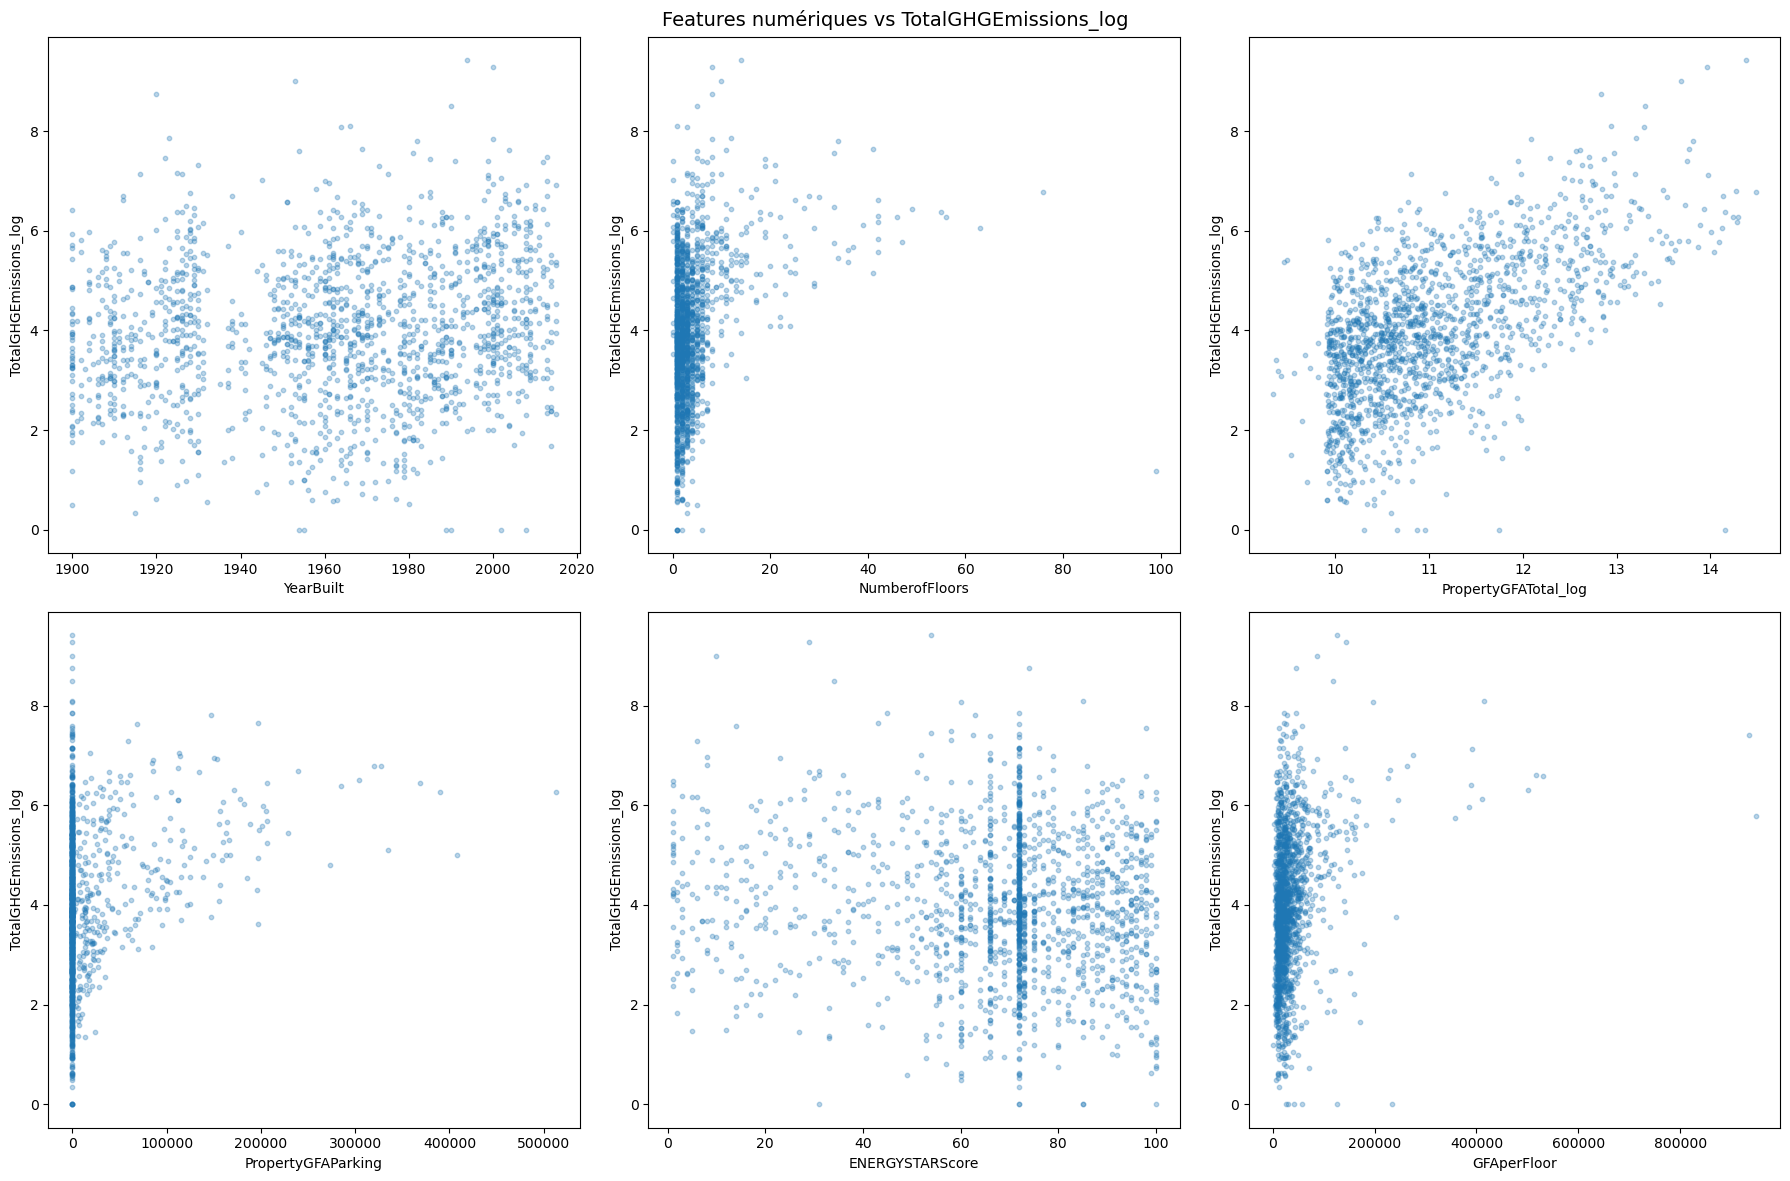

In [39]:
num_features = [
    'YearBuilt', 
    'NumberofFloors', 'PropertyGFATotal_log', 'PropertyGFAParking',
    'ENERGYSTARScore' ,
    'GFAperFloor'
]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].scatter(building_consumption[col], 
                    building_consumption['TotalGHGEmissions_log'], 
                    alpha=0.3, s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('TotalGHGEmissions_log')

plt.suptitle("Features numériques vs TotalGHGEmissions_log", fontsize=14)
plt.tight_layout()
plt.show()

## Features catégorielles vs TotalGHGEmissions_log (quali vs quanti)

### BuildingType
Les différents types de bâtiments montrent des niveaux d'émissions distincts.
Nonresidential COS (ville de Seattle) et SPS-District K-12 (écoles publiques)
ont des médianes plus élevées que NonResidential standard, ce qui suggère que
le type de bâtiment est une feature pertinente pour la prédiction.

### PrimaryPropertyType
C'est la variable catégorielle la plus discriminante :
- **Hospital** et **Large Office** ont les émissions les plus élevées
- **Refrigerated Warehouse** et **Restaurant** ont des médianes élevées
- **Worship Facility** et **Self-Storage Facility** ont les émissions les plus faibles
- Les boîtes sont bien séparées entre les types → forte valeur prédictive

### LargestPropertyUseType
Trop de catégories (plus de 60) pour être lisible directement.
La tendance est similaire à PrimaryPropertyType mais plus granulaire.
Cette colonne pourrait être regroupée en moins de catégories pour
améliorer les performances du modèle.

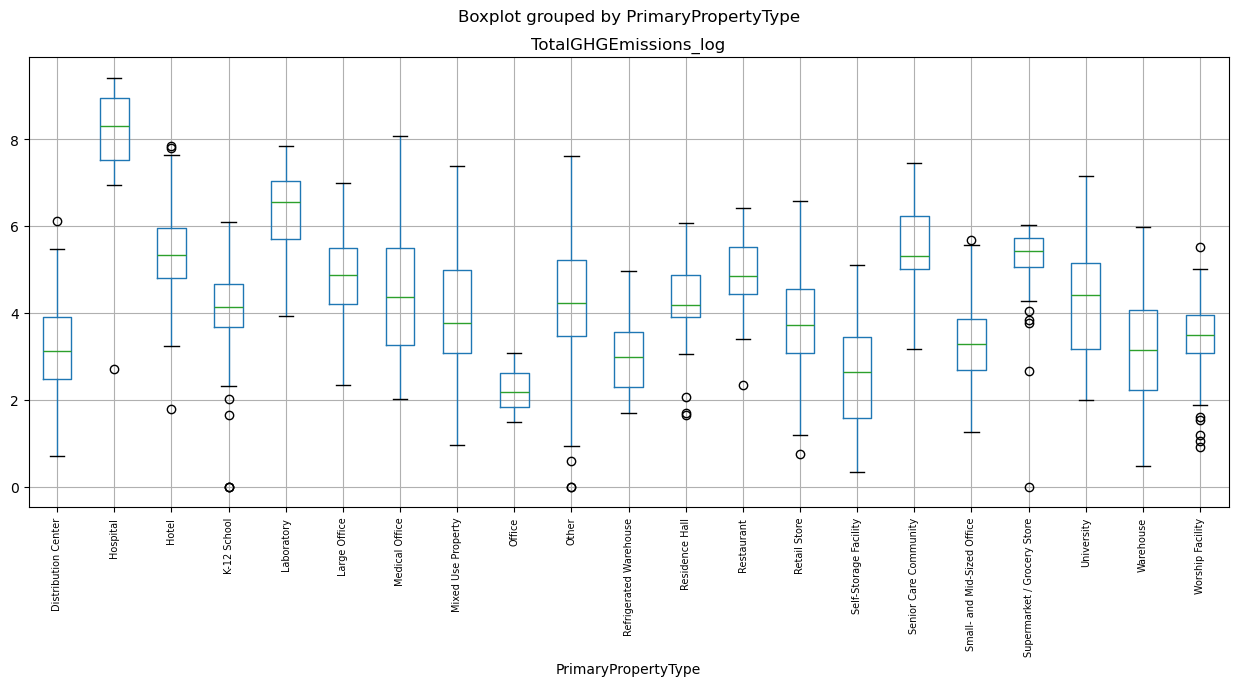

In [40]:
fig, ax = plt.subplots(figsize=(15, 6))
building_consumption.boxplot(column='TotalGHGEmissions_log', 
                              by='PrimaryPropertyType', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
plt.show()

In [41]:
# Vérification finale
print("Shape :", building_consumption.shape)
print("\nNaN :", building_consumption.isnull().sum().sum())
print("\nDoublons :", building_consumption.duplicated().sum())
print("\nTypes :\n", building_consumption.dtypes)

Shape : (1623, 12)

NaN : 0

Doublons : 0

Types :
 PrimaryPropertyType      category
Neighborhood             category
YearBuilt                   int64
NumberofFloors              int64
PropertyGFATotal_log      float64
PropertyGFAParking          int64
ENERGYSTARScore           float64
TotalGHGEmissions_log     float64
GFAperFloor               float64
HasParking                  int64
HasGas                      int64
HasSteam                    int64
dtype: object


In [42]:
building_consumption.isnull().sum()[building_consumption.isnull().sum() > 0]


Series([], dtype: int64)

## IQR
La limite haute et basse montrent des gros bâtiments qui peuvent fausser le modèle. Je ne les considère pas comment des Outlier.
Je les écartent pour la validation croisé et les utiliserai pour le test final

In [43]:
iqr = np.quantile(building_consumption.TotalGHGEmissions_log, q=[0.25, 0.75])
limite_basse = iqr[0] - 1.5*(iqr[1] - iqr[0])
limite_haute = iqr[1] + 1.5*(iqr[1] - iqr[0])

print(f'IQR = {iqr}')
print(f'limite_basse = {limite_basse}')
print(f'limite_haute ={ limite_haute}')

IQR = [3.0516389 4.925309 ]
limite_basse = 0.2411337521793766
limite_haute =7.735814145049467


In [45]:
# Normaliser la casse des quartiers
building_consumption['Neighborhood'] = building_consumption['Neighborhood'].str.upper().str.strip()

# Vérifier
building_consumption['Neighborhood'].value_counts()

Neighborhood
DOWNTOWN                  349
GREATER DUWAMISH          336
MAGNOLIA / QUEEN ANNE     147
LAKE UNION                146
NORTHEAST                 123
EAST                      118
NORTHWEST                  85
BALLARD                    70
NORTH                      67
CENTRAL                    51
SOUTHEAST                  46
DELRIDGE                   44
SOUTHWEST                  40
DELRIDGE NEIGHBORHOODS      1
Name: count, dtype: int64

## Vérification finale des valeurs manquantes

Après l'ensemble des étapes de nettoyage, une vérification finale révèle
4 valeurs manquantes résiduelles dans la colonne LargestPropertyUseType.

Ces NaN correspondent à des bâtiments dont l'usage principal détaillé
n'a pas été renseigné. On les impute par le mode (valeur la plus fréquente)
de la colonne, ce qui est la stratégie standard pour une variable catégorielle
avec peu de valeurs manquantes.

**Résultat final du dataset :**
- Lignes : 1624 bâtiments non résidentiels
- Colonnes : 15 features + 1 target
- Valeurs manquantes : 0
- Doublons : 0

Le dataset est propre et prêt pour la modélisation.

## Préparation des features pour la modélisation

### Suppression de BuildingType
Redondant avec PrimaryPropertyType — le type de bâtiment est déjà
capturé de façon plus détaillée par l'usage principal.
Exemple : SPS-District K-12 correspond toujours à K-12 School.

### Suppression de LargestPropertyUseType
56 valeurs uniques — le One-Hot Encoding aurait généré 55 colonnes
supplémentaires introduisant un risque de fléau de la dimensionnalité.
L'information est déjà capturée par PrimaryPropertyType (22 valeurs).
Les catégories rares ont été regroupées en "Other" mais la colonne
reste trop granulaire pour apporter une valeur ajoutée significative.

### Séparation X et y
- **X** : DataFrame de 1624 lignes × 56 features
- **y** : Series de 1624 valeurs (TotalGHGEmissions_log)

### Encodage des variables catégorielles
Les 4 colonnes catégorielles ont été encodées en One-Hot Encoding :
- PrimaryPropertyType (22 valeurs)
- Neighborhood (19 valeurs)
drop_first=True a été utilisé pour éviter la multicolinéarité
(dummy variable trap) — pour N catégories, N-1 colonnes sont créées.

In [46]:
# CODE PREPARATION DES FEATURES
# Vérification
print(building_consumption.shape)
print(building_consumption.columns.tolist())

(1623, 12)
['PrimaryPropertyType', 'Neighborhood', 'YearBuilt', 'NumberofFloors', 'PropertyGFATotal_log', 'PropertyGFAParking', 'ENERGYSTARScore', 'TotalGHGEmissions_log', 'GFAperFloor', 'HasParking', 'HasGas', 'HasSteam']


In [47]:
# Séparation X et y
X = building_consumption.drop(columns=['TotalGHGEmissions_log'])
y = building_consumption['TotalGHGEmissions_log']

# One-Hot Encoding
enc = OneHotEncoder(sparse_output=False, drop='first',max_categories = 15)
cat_cols = ['PrimaryPropertyType', 'Neighborhood']
encoded = enc.fit_transform(X[cat_cols])
encoded_cols = enc.get_feature_names_out(cat_cols)
encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=X.index)
X = pd.concat([X, encoded_df], axis=1)
X = X.drop(columns=cat_cols)
print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")

Shape X : (1623, 36)
Shape y : (1623,)


In [48]:
print(X.select_dtypes(include=['object', 'category']).columns.tolist())


[]


In [49]:
# CODE COMPARAISON DES MODELES
mask_outliers = (y < limite_basse) | (y > limite_haute)
X_train = X[~mask_outliers]
y_train = y[~mask_outliers]
X_outliers = X[mask_outliers]
y_outliers = y[mask_outliers]


print(f"X_train : {X_train.shape}")
print(f"X_outliers : {X_outliers.shape}")

X_train : (1607, 36)
X_outliers : (16, 36)


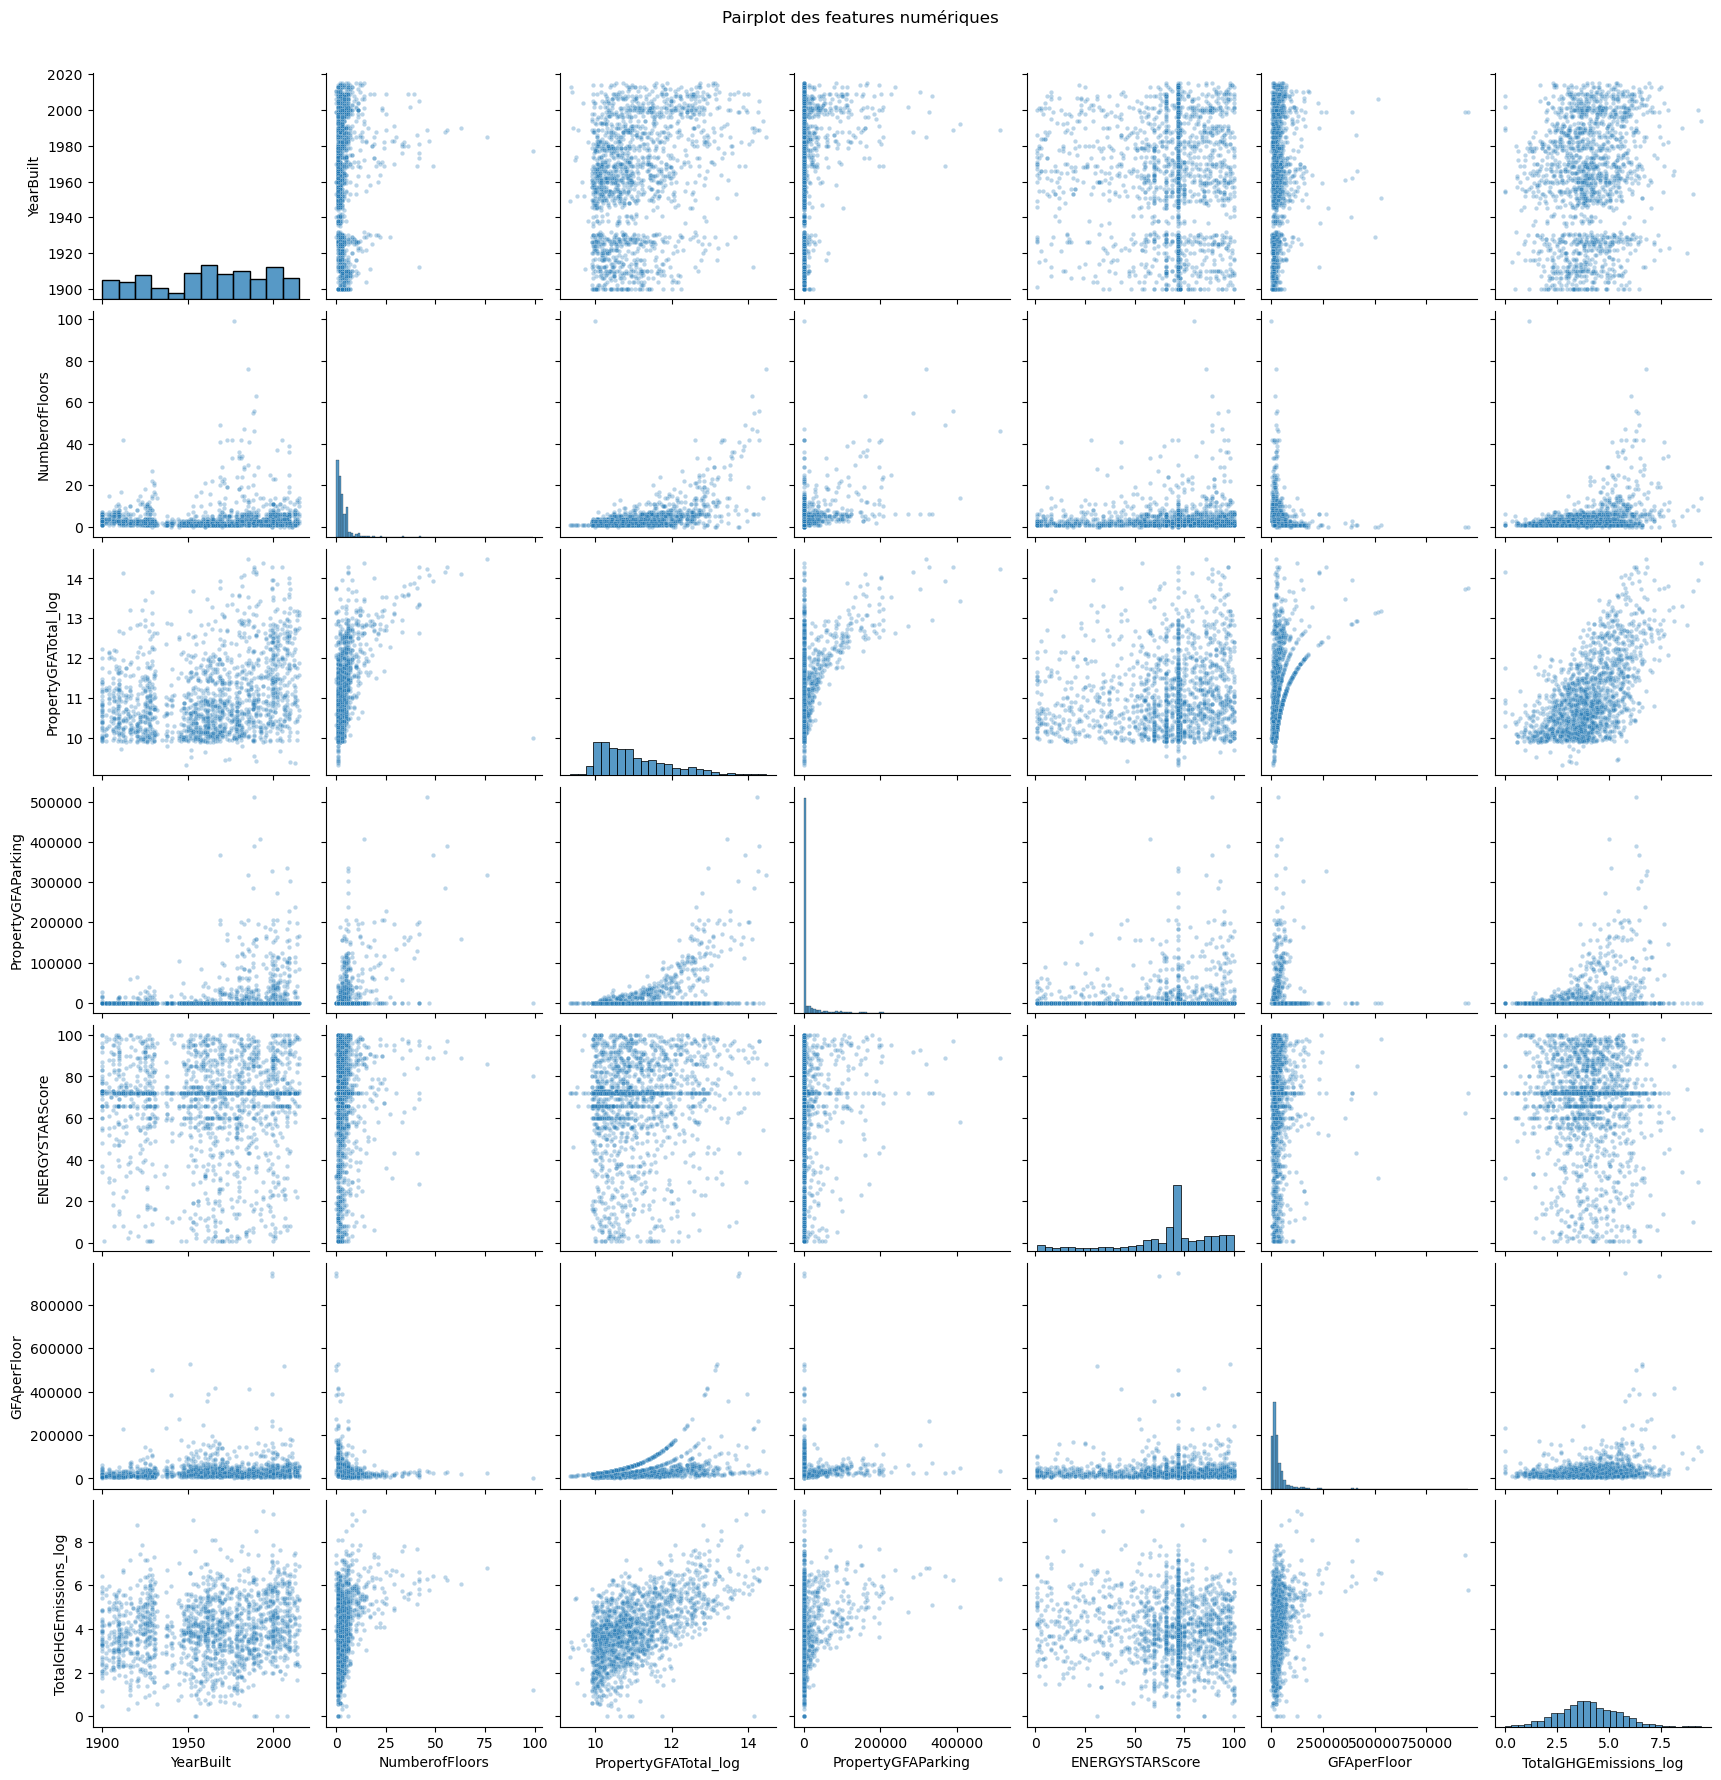

In [50]:
# Pairplot des features numériques vs target
num_features = [
    'YearBuilt', 'NumberofFloors', 'PropertyGFATotal_log',
    'PropertyGFAParking', 
    'ENERGYSTARScore', 
    'GFAperFloor',
     'TotalGHGEmissions_log'
]

sns.pairplot(building_consumption[num_features], 
             plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle("Pairplot des features numériques", y=1.02)
plt.show()

## Comparaison de différents modèles supervisés
A réaliser :

Pour chaque algorithme que vous allez tester, vous devez : Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée. Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable. Entrainer le modèle sur le jeu de Train Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence). Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test. Interpréter les résultats pour juger de la fiabilité de l'algorithme. Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM Déterminer le modèle le plus performant parmi ceux testés.

In [51]:
# Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_outliers_scaled = scaler.transform(X_outliers)

print(f"X_train_scaled : {X_train_scaled.shape}")

X_train_scaled : (1607, 36)


## Comparaison de modèles supervisés

### Démarche
Pour comparer les modèles on utilise une validation croisée à 5 folds (KFold)
sur le jeu d'entraînement (sans outliers). Pour chaque fold, le modèle est
entraîné sur 4/5 des données et évalué sur 1/5.

Les métriques calculées sont :
- **R²** : part de variance expliquée (proche de 1 = bon)
- **MAE** : erreur absolue moyenne (même unité que la target)
- **RMSE** : erreur quadratique moyenne (pénalise les grandes erreurs)

In [52]:
def perform_cross_validation(
    X_train,
    y_train,
    model,
    cross_val_type,
    scoring_metrics: tuple,
    return_estimator=False,
    groups=None,
):
    scores = cross_validate(
        model,
        X_train,  
        y_train,
        cv=cross_val_type,
        return_train_score=True,
        return_estimator=return_estimator,
        scoring=scoring_metrics,
        groups=groups,
    )
    for metric in scoring_metrics:
        print(f"Average Train {metric} : {np.mean(scores['train_' + metric]):.4f}")
        print(f"Train {metric} Std : {np.std(scores['train_' + metric]):.4f}")
        print(f"Average Test {metric} : {np.mean(scores['test_' + metric]):.4f}")
        print(f"Test {metric} Std : {np.std(scores['test_' + metric]):.4f}")
        print("---")
    return scores

In [53]:
#Inférence - Régression Linéaire
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring_metrics = ('r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error')

scores_lr = perform_cross_validation(
    X_train=X_train,
    y_train=y_train,
    model=LinearRegression(),
    cross_val_type=cv,
    scoring_metrics=scoring_metrics
)

Average Train r2 : 0.7293
Train r2 Std : 0.0022
Average Test r2 : 0.7103
Test r2 Std : 0.0101
---
Average Train neg_mean_absolute_error : -0.5543
Train neg_mean_absolute_error Std : 0.0055
Average Test neg_mean_absolute_error : -0.5707
Test neg_mean_absolute_error Std : 0.0245
---
Average Train neg_root_mean_squared_error : -0.7091
Train neg_root_mean_squared_error Std : 0.0047
Average Test neg_root_mean_squared_error : -0.7325
Test neg_root_mean_squared_error Std : 0.0205
---


In [54]:
# Inférence - SVR
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring_metrics = ('r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error')

scores_svr = perform_cross_validation(
    X_train=X_train_scaled,
    y_train=y_train,
    model=SVR(),
    cross_val_type=cv,
    scoring_metrics=scoring_metrics
)

Average Train r2 : 0.7936
Train r2 Std : 0.0027
Average Test r2 : 0.6888
Test r2 Std : 0.0074
---
Average Train neg_mean_absolute_error : -0.4374
Train neg_mean_absolute_error Std : 0.0022
Average Test neg_mean_absolute_error : -0.5802
Test neg_mean_absolute_error Std : 0.0174
---
Average Train neg_root_mean_squared_error : -0.6191
Train neg_root_mean_squared_error Std : 0.0033
Average Test neg_root_mean_squared_error : -0.7593
Test neg_root_mean_squared_error Std : 0.0208
---


In [55]:
# Inférence - RandomForest
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring_metrics = ('r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error')
scores_rf = perform_cross_validation(
    X_train=X_train,
    y_train=y_train,
    model=RandomForestRegressor(random_state=42),
    cross_val_type=cv,
    scoring_metrics=scoring_metrics
)

Average Train r2 : 0.9564
Train r2 Std : 0.0009
Average Test r2 : 0.6813
Test r2 Std : 0.0157
---
Average Train neg_mean_absolute_error : -0.2146
Train neg_mean_absolute_error Std : 0.0014
Average Test neg_mean_absolute_error : -0.5815
Test neg_mean_absolute_error Std : 0.0128
---
Average Train neg_root_mean_squared_error : -0.2845
Train neg_root_mean_squared_error Std : 0.0021
Average Test neg_root_mean_squared_error : -0.7680
Test neg_root_mean_squared_error Std : 0.0159
---


### Résultats

| Modèle | R² Train | R² Test | MAE Test | RMSE Test | Overfit |
|--------|----------|---------|----------|-----------|---------|
| Régression Linéaire | 0.73 | **0.71** | **0.57** | **0.73** | ✅ Non |
| SVR | 0.79 | 0.69 | 0.58 | 0.76 | ⚠️ Léger |
| Random Forest | 0.96 | 0.68 | 0.58 | 0.77 | ❌ Fort |

### Conclusion

La régression linéaire obtient les meilleures performances et la meilleure
stabilité sur le modèle réduit à 9 features. Cela s'explique par la nature
du problème : les émissions CO2 d'un bâtiment sont principalement déterminées
par des relations proportionnelles — surface, ancienneté, type d'énergie —
qui correspondent précisément aux hypothèses d'un modèle linéaire.

La réduction de 18 à 9 features (sélectionnées par Permutation Importance)
n'entraîne qu'une perte marginale de performance (R² : 0.713 → 0.710),
confirmant que les features supprimées apportaient peu d'information.

Les modèles non linéaires (Random Forest, SVR) overfitent avec leurs
paramètres par défaut car ils cherchent des patterns complexes qui
n'existent pas dans ces données. Le Random Forest est particulièrement
affecté avec un écart de 0.27 entre train et test.

**Modèle final retenu : Régression Linéaire avec 9 features (R² = 0.710)**

### Optimisation et interprétation du modèle
A réaliser :

Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [56]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE

In [57]:

param_grid = {
    'n_estimators': [300, 400, 500],
    'max_depth': [12, 15, 18],
    'min_samples_leaf': [2, 3, 4],
    'max_features': [0.3, 0.5, 0.7]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    return_train_score=True,
    n_jobs=-1  # utilise tous les cœurs disponibles
)

grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur R² : {grid_search.best_score_:.4f}")

Meilleurs paramètres : {'max_depth': 18, 'max_features': 0.3, 'min_samples_leaf': 2, 'n_estimators': 400}
Meilleur R² : 0.6969


### Résultat final de la GridSearch

Après optimisation du Random Forest sur le modèle réduit à 9 features,
le meilleur R² obtenu est 0.699, toujours inférieur à la régression
linéaire (R² = 0.710).

Meilleurs paramètres trouvés :
- max_depth : 18
- max_features : 0.3
- min_samples_leaf : 2
- n_estimators : 500

**Modèle final retenu : Régression Linéaire (R² test = 0.710)**

Ce résultat confirme l'analyse métier : les émissions CO2 des bâtiments
suivent des relations principalement linéaires avec leurs caractéristiques
structurelles. La réduction à 9 features ne change pas cette conclusion.

## Interprétation de la Permutation Importance

### Features les plus importantes

- **PropertyGFATotal_log** : feature dominante de loin — la surface totale
  est le principal déterminant des émissions CO2. Physiquement logique et
  donnée structurelle disponible sans mesure préalable.

- **HasGas** : deuxième feature — le raccordement au gaz naturel est une
  caractéristique structurelle connue sans mesure de consommation.
  Le gaz étant plus émetteur que l'électricité, son impact sur les
  émissions CO2 est direct.

- **PrimaryPropertyType_Other** : troisième feature — cette catégorie
  regroupe des bâtiments très hétérogènes (parkings, musées, prisons,
  cinémas...) aux profils énergétiques variés, ce qui explique son poids
  dans le modèle.

- **ENERGYSTARScore** : sixième feature — confirme la pertinence de
  l'imputation par médiane par groupe malgré les 549 NaN initiaux.

- **PrimaryPropertyType_infrequent_sklearn** : catégories rares de
  PrimaryPropertyType regroupées automatiquement par OneHotEncoder
  (max_categories=15) — correspond aux types de bâtiments peu représentés
  dans le dataset.

### Features peu importantes
- **Latitude / Longitude** → confirme que la localisation géographique
  seule n'est pas prédictive des émissions
- **HasParking, HasElectricity, NombreUsages** → impact faible
- **DefaultData** → sans impact sur les prédictions

### Limite identifiée — catégorie "Other"
L'analyse de LargestPropertyUseType révèle que PrimaryPropertyType_Other
regroupe 36 types d'usage très hétérogènes. Les prédictions sur les
bâtiments de type "Other" sont donc moins fiables que sur les autres types.
Cette limite a motivé la création du notebook 2.

Modèle sauvegardé : Model(tag="seattle_ghg_model:stjahvs2rkmlmzcj")


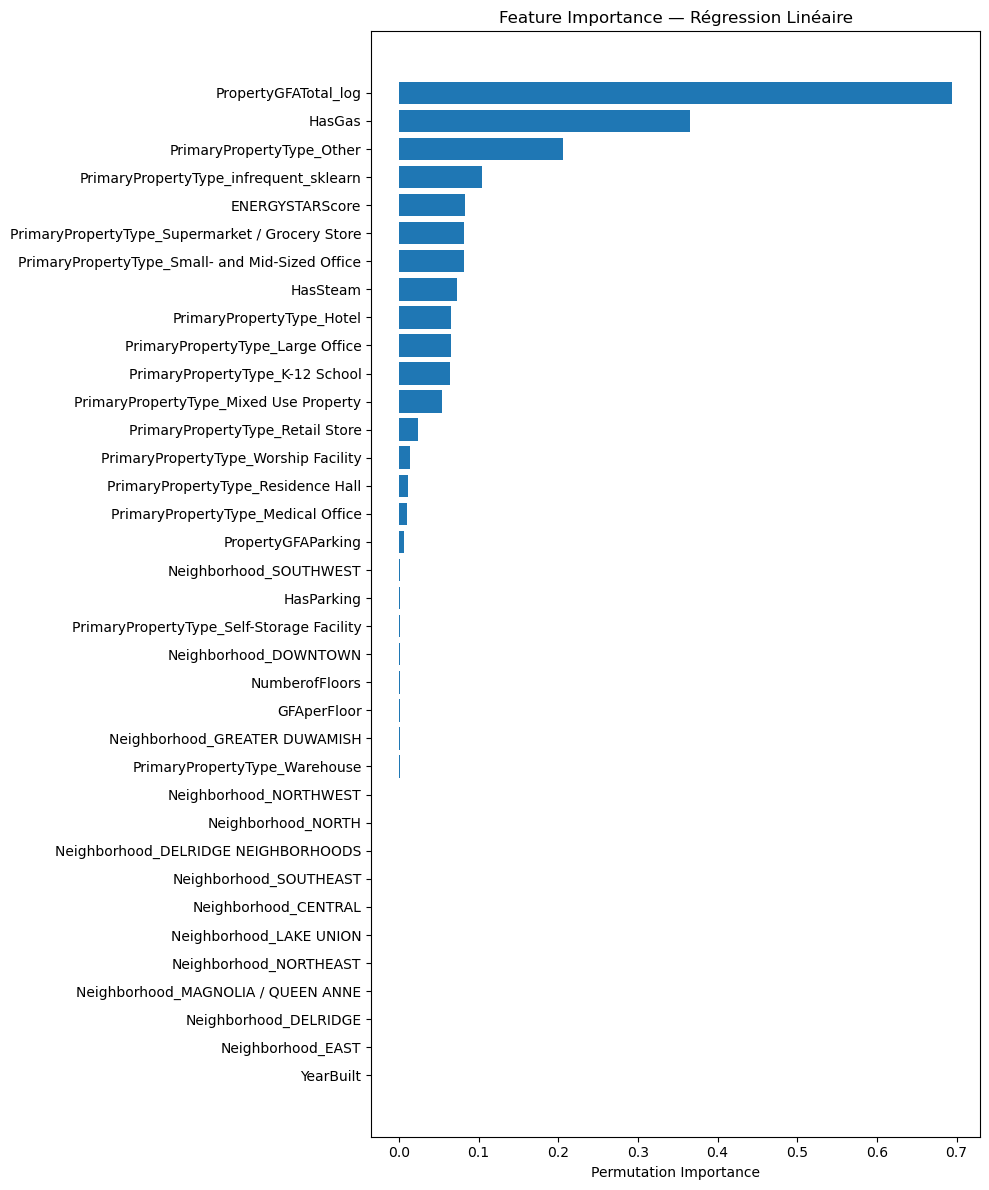

In [58]:
# Entraîner le modèle final sur tout X_train
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Sauvegarder avec BentoML
saved_model = bentoml.sklearn.save_model(
    "seattle_ghg_model",
    model_lr,
    custom_objects={
        "encoder": enc,          # OneHotEncoder
        "feature_names": list(X_train.columns),  # ordre des features
    },
    signatures={
        "predict": {
            "batchable": True,
        }
    }
)

print(f"Modèle sauvegardé : {saved_model}")

# Permutation Importance
result = permutation_importance(
    model_lr, X_train, y_train, 
    n_repeats=10, 
    random_state=42,
    n_jobs=-1
)

# Afficher sous forme d'histogramme
feature_names = X_train.columns
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 12))
plt.barh(feature_names[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Feature Importance — Régression Linéaire")
plt.tight_layout()
plt.show()

### Résultats comparatifs — Test sans ENERGYSTARScore

| Modèle | R² avec | R² sans | MAE avec | MAE sans |
|--------|---------|---------|----------|----------|
| Régression Linéaire | **0.710** | 0.675 | **0.571** | 0.612 |
| Random Forest | 0.681 | 0.658 | 0.582 | 0.603 |
| SVR | 0.689 | 0.659 | 0.580 | 0.609 |

### Conclusion

Supprimer ENERGYSTARScore dégrade les performances sur les 3 modèles.
Malgré les 549 NaN imputés par médiane par groupe, cette feature apporte
une information réelle au modèle.

L'imputation par médiane par groupe (par PrimaryPropertyType) s'avère
être une bonne stratégie — elle a permis de conserver une feature utile
sans introduire de bruit significatif.

**ENERGYSTARScore est conservé dans le modèle final.**

## Conclusion générale

### Objectif du projet
Prédire les émissions CO2 (TotalGHGEmissions) de bâtiments non résidentiels
de Seattle à partir de leurs caractéristiques structurelles, sans mesure
énergétique préalable.

### Démarche suivie
1. **Nettoyage** : suppression des bâtiments résidentiels, outliers signalés
   par la ville, valeurs manquantes inexploitables et bâtiment atypique
   (Bullitt Center). Dataset final : 1623 bâtiments.

2. **Feature Engineering** : création de 6 nouvelles features structurelles
   (GFAperFloor, HasParking, HasElectricity, HasGas, HasSteam, NombreUsages).

3. **Modélisation** : comparaison de 3 modèles — la régression linéaire
   s'impose comme le meilleur modèle (R² = 0.713, sans overfit).

4. **Optimisation** : GridSearch sur Random Forest confirme la supériorité
   de la régression linéaire.

5. **Interprétation** : la surface (PropertyGFATotal_log) et le type
   d'énergie (HasGas) sont les principaux déterminants des émissions CO2.

### Résultats clés
- **Modèle final** : Régression Linéaire
- **R² test** : 0.713 — le modèle explique 71% de la variance des émissions,
  ce qui est considéré comme un bon score pour une prédiction basée
  uniquement sur des caractéristiques structurelles sans mesure préalable.
- **MAE** : 0.40
- **Pas d'overfit** — scores train et test très proches

### Limites identifiées
- La catégorie "Other" regroupe des bâtiments trop hétérogènes
- Les hôpitaux et grandes universités (outliers) ont été exclus
  de l'entraînement — leurs émissions sont difficilement prédictibles
  sans données supplémentaires (nombre de lits, équipements médicaux...)
- Un R² de 0.71 laisse 29% de variance inexpliquée — des données
  supplémentaires (année de rénovation, type de chauffage, certification
  environnementale) pourraient améliorer le modèle

In [67]:
X_train_no_energy_scaled = scaler.fit_transform(X_train_no_energy)

scores_svr_no_energy = perform_cross_validation(
    X_train=X_train_no_energy_scaled,
    y_train=y_train,
    model=SVR(),
    cross_val_type=cv,
    scoring_metrics=scoring_metrics
)

Average Train r2 : 0.7612
Train r2 Std : 0.0024
Average Test r2 : 0.6585
Test r2 Std : 0.0108
---
Average Train neg_mean_absolute_error : -0.4778
Train neg_mean_absolute_error Std : 0.0054
Average Test neg_mean_absolute_error : -0.6090
Test neg_mean_absolute_error Std : 0.0267
---
Average Train neg_root_mean_squared_error : -0.6659
Train neg_root_mean_squared_error Std : 0.0044
Average Test neg_root_mean_squared_error : -0.7955
Test neg_root_mean_squared_error Std : 0.0250
---
